In [1]:
# enable lokal import
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent  
SRC_DIR = ROOT_DIR / "src"

sys.path.insert(0, str(SRC_DIR)) 

%matplotlib inline
import matplotlib.pyplot as plt
plt.ioff()

#### Initial state  and martices for constructing the J gate 

In [2]:
from ewl import EWL

from ewl.parametrizations import U_theta_alpha_beta

import sympy as sp
from sympy import Array, Matrix
from sympy.physics.quantum.qubit import Qubit


from qiskit.visualization import plot_histogram

sp.init_printing()

i = sp.I
pi = sp.pi
sqrt2 = sp.sqrt(2)

In [3]:
psi = (Qubit('00') + i * Qubit('11')) / sqrt2
psi

In [4]:
C = Matrix([
    [1, 0],
    [0, 1],
])
C

⎡1  0⎤
⎢    ⎥
⎣0  1⎦

In [5]:
D = Matrix([
    [0, i],
    [i, 0],
])
D

⎡0  ⅈ⎤
⎢    ⎥
⎣ⅈ  0⎦

#### Payoff matrix

In [6]:
payoff_matrix = Array([
    [
        [3, 1],
        [0, 2],
    ],
    [
        [2, 1],
        [0, 3],
    ],
])
payoff_matrix

⎡⎡3  1⎤  ⎡2  1⎤⎤
⎢⎢    ⎥  ⎢    ⎥⎥
⎣⎣0  2⎦  ⎣0  3⎦⎦

#### Pauli matrices  

In [7]:
I= Matrix([
    [1, 0],
    [0, 1],
])

In [8]:
X= Matrix([
    [0, 1],
    [1, 0],
])

In [9]:
Y= Matrix([
    [0, -i],
    [i, 0],
])

In [10]:
Z=Matrix([
    [1, 0],
    [0, -1],
])

#### Player strategies

In [11]:
U3 = (I+i*Z)/ sqrt2
U3

⎡√2⋅(1 + ⅈ)            ⎤
⎢──────────      0     ⎥
⎢    2                 ⎥
⎢                      ⎥
⎢            √2⋅(1 - ⅈ)⎥
⎢    0       ──────────⎥
⎣                2     ⎦

In [12]:
U4 = i*(X+Y)/sqrt2
U4

⎡              √2⋅ⅈ⋅(1 - ⅈ)⎤
⎢     0        ────────────⎥
⎢                   2      ⎥
⎢                          ⎥
⎢√2⋅ⅈ⋅(1 + ⅈ)              ⎥
⎢────────────       0      ⎥
⎣     2                    ⎦

### (iX, iX) strategy - symbolic execution step by step

In [13]:
alice=i*X
bob=i*X

In [14]:
ewl = EWL(psi=psi, C=C, D=D, players=[alice, bob], payoff_matrix=payoff_matrix)
ewl

In [15]:
ewl.J

⎡ √2               -√2⋅ⅈ ⎤
⎢ ──    0     0    ──────⎥
⎢ 2                  2   ⎥
⎢                        ⎥
⎢      √2⋅ⅈ  -√2         ⎥
⎢ 0    ────  ────    0   ⎥
⎢       2     2          ⎥
⎢                        ⎥
⎢      -√2   √2⋅ⅈ        ⎥
⎢ 0    ────  ────    0   ⎥
⎢       2     2          ⎥
⎢                        ⎥
⎢√2⋅ⅈ               -√2  ⎥
⎢────   0     0     ──── ⎥
⎣ 2                  2   ⎦

In [16]:
ewl.J_H

⎡ √2                   -√2⋅ⅈ ⎤
⎢ ──     0       0     ──────⎥
⎢ 2                      2   ⎥
⎢                            ⎥
⎢      -√2⋅ⅈ    -√2          ⎥
⎢ 0    ──────   ────     0   ⎥
⎢        2       2           ⎥
⎢                            ⎥
⎢       -√2    -√2⋅ⅈ         ⎥
⎢ 0     ────   ──────    0   ⎥
⎢        2       2           ⎥
⎢                            ⎥
⎢√2⋅ⅈ                   -√2  ⎥
⎢────    0       0      ──── ⎥
⎣ 2                      2   ⎦

In [17]:
ewl.amplitudes(simplify=False)

⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣1⎦

In [18]:
ewl.amplitudes()

⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣1⎦

In [19]:
ewl.probs()

⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣1⎦

In [20]:
(ewl.payoff_function(player=0), ewl.payoff_function(player=1))

#### Different strategies test
$$
\begin{array}{c|cccc}
 & I & iX & U_3 & U_4 \\
\hline
I & (3,2) & (1,1) & \left(\frac{5}{2},\frac{5}{2}\right) & \left(\frac{1}{2},\frac{1}{2}\right) \\
iX & (0,0) & (2,3) & \left(\frac{1}{2},\frac{1}{2}\right) & \left(\frac{5}{5},\frac{5}{5}\right) \\
U_3 & \left(\frac{5}{2},\frac{5}{2}\right) & \left(\frac{1}{2},\frac{1}{2}\right) & (2,3) & (0,0) \\
U_4 & \left(\frac{1}{2},\frac{1}{2}\right) & \left(\frac{5}{2},\frac{5}{2}\right) & (1,1) & (3,2) \\
\end{array}
$$

In [21]:
alice=U4
bob=U3
ewl = EWL(psi=psi, C=C, D=D, players=[alice, bob], payoff_matrix=payoff_matrix)
(ewl.payoff_function(player=0), ewl.payoff_function(player=1))

In [28]:
alice=U3
bob=I
ewl = EWL(psi=psi, C=C, D=D, players=[alice, bob], payoff_matrix=payoff_matrix)
(ewl.payoff_function(player=0), ewl.payoff_function(player=1))


#### Probabilities

In [29]:
ewl.probs()

⎡1/2⎤
⎢   ⎥
⎢ 0 ⎥
⎢   ⎥
⎢ 0 ⎥
⎢   ⎥
⎣1/2⎦

### Statevector simulator IBM

In [30]:
from ewl.ibmq import EWL_IBMQ
ewl_ibmq = EWL_IBMQ(ewl)
ewl_ibmq

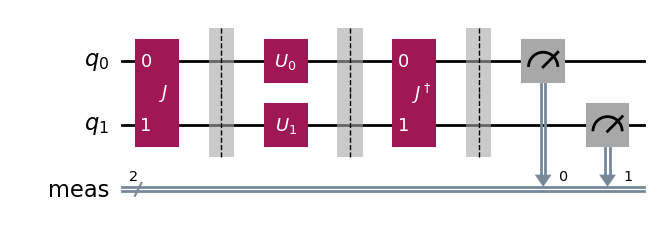

In [31]:
ewl_ibmq.draw()


{np.str_('00'): np.float64(0.5000000000000002), np.str_('11'): np.float64(0.5000000000000002)}


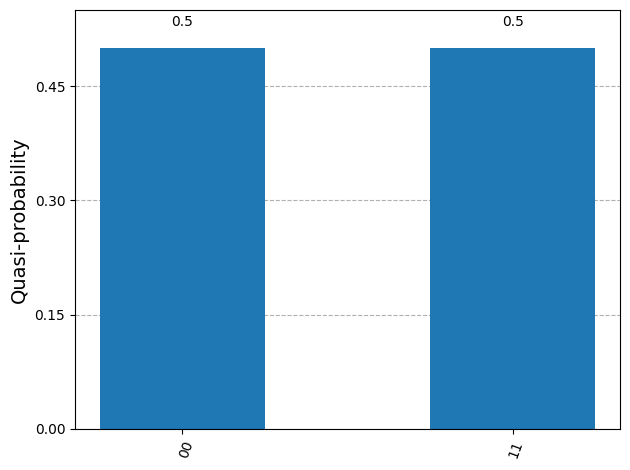

In [32]:
probs = ewl_ibmq.simulate_probs()
print(probs)
plot_histogram(probs)

{np.str_('00'): np.int64(526), np.str_('11'): np.int64(498)}


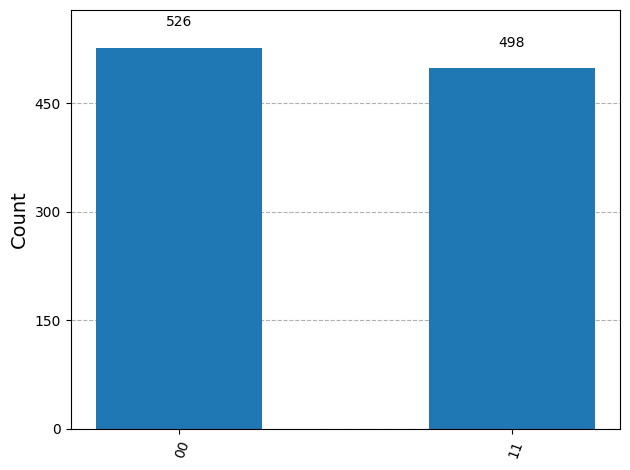

In [33]:
counts_qasm_simulator = ewl_ibmq.simulate_counts()
print(counts_qasm_simulator)
plot_histogram(counts_qasm_simulator)

### Transpiled circuit preview

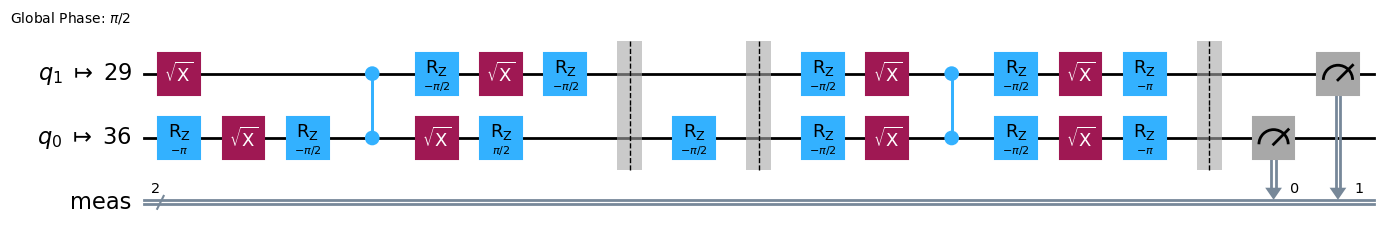

In [34]:
ewl_ibmq.draw_transpiled(backend_name='ibm_torino', optimization_level=3, fold=-1)

### Actual Run

{'00': 509, '11': 468, '01': 19, '10': 28}


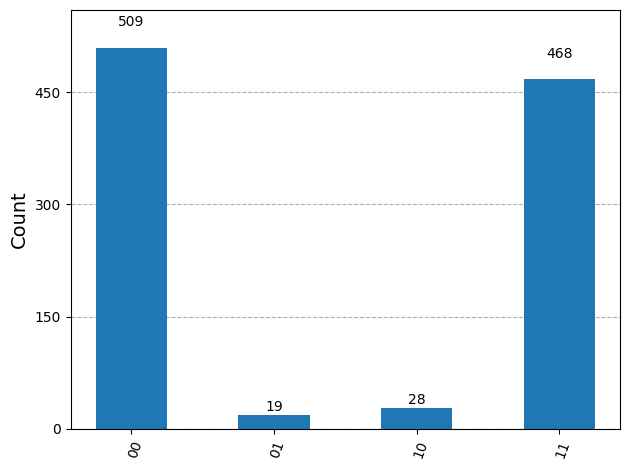

In [35]:
counts_quantum_device = ewl_ibmq.run()
print(counts_quantum_device)
plot_histogram(counts_quantum_device)

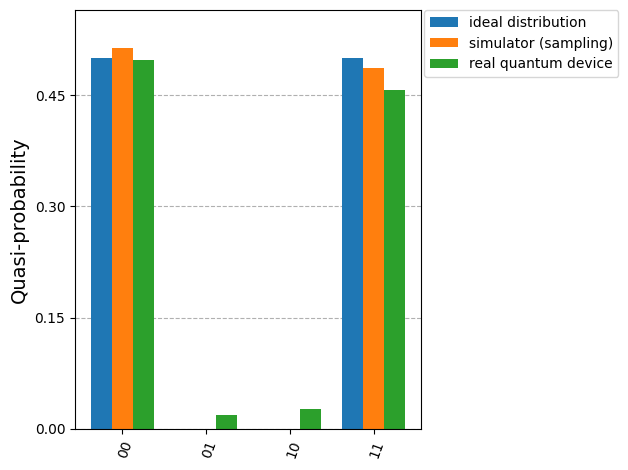

In [36]:
binary_prob = [probs, counts_qasm_simulator, counts_quantum_device]
plot_histogram(
    binary_prob,
    bar_labels=False,
    legend=['ideal distribution', 'simulator (sampling)', 'real quantum device']       
)